# Channel Video Geometry (Shared 20D Space)

This notebook characterizes each channel's video cloud geometry in one **shared 20-dimensional space**. It intentionally excludes engagement modeling and instead produces reusable geometry artifacts for downstream prediction and graph-overlay analyses.

## Interpretation scope

This notebook measures the geometry of channel video clouds before any engagement modeling. The purpose is to test whether channels behave like compact isotropic clouds, elongated anisotropic clouds, or multimodal semantic manifolds. Later notebooks can overlay engagement and the subscription graph onto these shared-space geometric artifacts.

## 1) Setup and reproducibility

We import libraries, define reproducible configuration, and create artifact folders. Thresholds and tuning knobs are centralized here so results are inspectable and rerunnable.

In [1]:

import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


CONFIG = {
    # Canonical export path documented in docs/Graphiko/fetch_videos_embeddings_analysis.md
    "input_csv": Path("/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv"),
    "fallback_inputs": [
        Path("data/business_cluster_video_embeddings_reduced_20d.csv"),
        Path("data/video_embeddings_reduced_20d.csv"),
    ],
    "embedding_dim": 20,
    "time_decay_half_life_days": 180.0,
    "knn_k": 5,
    "min_prior_for_novelty": 5,
    "hdbscan_min_cluster_size": 6,
    "hdbscan_min_samples": 4,
    "mode_min_size_for_centroid_distance": 3,
    "output_root": Path("artifacts/channel_video_geometry"),
}

OUTPUT = CONFIG["output_root"]
PLOTS = OUTPUT / "plots"
PLOTS_CHANNEL = PLOTS / "per_channel"
PLOTS_CROSS = PLOTS / "cross_channel"
for d in [OUTPUT, PLOTS, PLOTS_CHANNEL, PLOTS_CROSS]:
    d.mkdir(parents=True, exist_ok=True)

pd.options.display.max_columns = 200
sns.set_theme(style="whitegrid")
print("Seed:", RANDOM_SEED)
print("Output:", OUTPUT.resolve())


Seed: 42
Output: /content/artifacts/channel_video_geometry


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2) Load canonical reduced-embedding export

We load the documented CSV export (`business_cluster_video_embeddings_reduced_20d.csv`), verify required columns, and construct a canonical table with identifiers, timestamps, and a 20D embedding vector per video.

In [3]:

def resolve_input_path():
    if CONFIG["input_csv"].exists():
        return CONFIG["input_csv"]
    for p in CONFIG["fallback_inputs"]:
        if p.exists():
            return p
    checked = [CONFIG["input_csv"], *CONFIG["fallback_inputs"]]
    raise FileNotFoundError("Could not find reduced embedding CSV. Checked: " + ", ".join(str(x) for x in checked))


input_path = resolve_input_path()
raw = pd.read_csv(input_path)
print("Loaded:", input_path)
print("Rows:", len(raw))

required_base = {"video_id", "channel_id", "video_title", "date_published"}
missing_base = sorted(required_base - set(raw.columns))
if missing_base:
    raise ValueError(f"Missing required base columns: {missing_base}")

embed_cols = [f"embedding_reduced_{i:02d}" for i in range(1, CONFIG["embedding_dim"] + 1)]
missing_embed = [c for c in embed_cols if c not in raw.columns]
if missing_embed:
    raise ValueError(f"Missing reduced embedding columns: {missing_embed}")

# Optional metadata (if available).
if "channel_name" not in raw.columns and "channel_title" in raw.columns:
    raw["channel_name"] = raw["channel_title"]
if "channel_name" not in raw.columns:
    raw["channel_name"] = np.nan
if "channel_description" not in raw.columns:
    raw["channel_description"] = np.nan

video_df = pd.DataFrame({
    "videoId": raw["video_id"],
    "channelId": raw["channel_id"],
    "title": raw["video_title"],
    "publishedAt": pd.to_datetime(raw["date_published"], utc=True, errors="coerce"),
    "channelNameExport": raw["channel_name"],
    "channelDescription": raw["channel_description"],
    "viewCount": pd.to_numeric(raw.get("view_count"), errors="coerce"),
    "likeCount": pd.to_numeric(raw.get("like_count"), errors="coerce"),
    "commentCount": pd.to_numeric(raw.get("comment_count"), errors="coerce"),
})

video_df["embedding"] = raw[embed_cols].to_numpy(dtype=float).tolist()


Loaded: /content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv
Rows: 1344


## 3) Validate global dataframe integrity

This block fails loudly if embeddings are not numeric finite 20D vectors, if timestamps are invalid, or if channel identifiers are missing.

In [4]:

X_check = np.vstack(video_df["embedding"].to_numpy())

if X_check.shape[1] != CONFIG["embedding_dim"]:
    raise ValueError(f"Expected {CONFIG['embedding_dim']} dimensions, got {X_check.shape[1]}")
if not np.isfinite(X_check).all():
    raise ValueError("Embeddings contain non-finite values")
if video_df["channelId"].isna().any():
    raise ValueError("Missing channelId values")
if video_df["publishedAt"].isna().any():
    bad = video_df.loc[video_df["publishedAt"].isna(), "videoId"].head(10).tolist()
    raise ValueError(f"Invalid publishedAt/date_published values. Example videoIds: {bad}")

# Human-readable primary label for outputs per coding guidelines.
video_df["channelName"] = video_df["channelNameExport"].fillna(video_df["channelId"].astype(str))

print("Validated videos:", len(video_df))
print("Validated channels:", video_df["channelId"].nunique())
video_df.head(3)


Validated videos: 1344
Validated channels: 27


,videoId,channelId,title,publishedAt,channelNameExport,channelDescription,viewCount,likeCount,commentCount,embedding,channelName
0,MIKej1HCRW0,UC-yRDvpR99LUc5l7i7jLzew,ChatGPT – The Super Assistant Era | BG2 Guest ...,2026-03-15 16:25:13+00:00,Bg2 Pod,Open Source bi-weekly convo w @altcap & @bgurl...,7574,128.0,12,"[-0.0792107707155629, -0.0360288198204415, 0.0...",Bg2 Pod
1,jA8ZQfq_Hzs,UC-yRDvpR99LUc5l7i7jLzew,AI Enterprise - Databricks & Glean | BG2 Guest...,2025-12-23 23:15:04+00:00,Bg2 Pod,Open Source bi-weekly convo w @altcap & @bgurl...,24210,324.0,163,"[-0.0898855541490583, -0.0365462490312498, 0.0...",Bg2 Pod
2,Gnl833wXRz0,UC-yRDvpR99LUc5l7i7jLzew,All things AI w @altcap @sama & @satyanadella....,2025-10-31 23:17:31+00:00,Bg2 Pod,Open Source bi-weekly convo w @altcap & @bgurl...,228167,3934.0,673,"[-0.1707287995488433, -0.0251555559002479, 0.1...",Bg2 Pod


## 4) Build one global 2D view (UMAP/PCA) for plotting only

All primary measurements stay in the original 20D space. We fit one global UMAP (and optional global PCA) across the full video set for consistent shared-space visualization.

In [5]:

X_all = np.vstack(video_df["embedding"].to_numpy())

pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca2.fit_transform(X_all)
video_df["pca2_x"] = X_pca2[:, 0]
video_df["pca2_y"] = X_pca2[:, 1]

try:
    import umap
except ImportError as e:
    raise ImportError("Please install umap-learn: pip install umap-learn") from e

umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=RANDOM_SEED,
)
X_umap2 = umap2.fit_transform(X_all)
video_df["umap2_x"] = X_umap2[:, 0]
video_df["umap2_y"] = X_umap2[:, 1]

print("Global UMAP complete for", len(video_df), "videos")


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Global UMAP complete for 1344 videos


## 5) Define geometry helper functions

These helpers compute medoids, shrinkage covariance, eigenspectra metrics, Mahalanobis distance, kNN density proxies, and temporal drift primitives used in per-channel loops.

In [6]:

def compute_medoid(X):
    D = pairwise_distances(X, metric="euclidean")
    idx = int(np.argmin(D.sum(axis=1)))
    return idx, X[idx]


def recency_weighted_centroid(X, published_at, half_life_days):
    tmax = published_at.max()
    age_days = (tmax - published_at).dt.total_seconds().to_numpy() / 86400.0
    w = 0.5 ** (age_days / half_life_days)
    w = np.clip(w, 1e-9, None)
    w = w / w.sum()
    return (X * w[:, None]).sum(axis=0)


def fit_shrinkage_covariance(X):
    model = LedoitWolf().fit(X)
    cov = model.covariance_
    precision = model.precision_
    evals = np.linalg.eigvalsh(cov)
    evals = np.sort(np.clip(evals, 0.0, None))[::-1]
    return cov, precision, evals


def effective_rank(evals, eps=1e-12):
    s = np.clip(np.asarray(evals, dtype=float), eps, None)
    p = s / s.sum()
    return float(np.exp(-(p * np.log(p)).sum()))


def mahalanobis_to_center(X, center, precision):
    diff = X - center
    vals = np.einsum("ij,jk,ik->i", diff, precision, diff)
    return np.sqrt(np.clip(vals, 0.0, None))


def knn_avg_distance(X, k):
    n = len(X)
    if n <= 1:
        return np.full(n, np.nan)
    k_eff = min(max(1, k), n - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric="euclidean")
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    return dists[:, 1:].mean(axis=1)


def density_percentile_from_knn(knn_dist):
    s = pd.Series(knn_dist)
    return (1.0 - s.rank(method="average", pct=True)).to_numpy()


def centroid_shift_first_second_half(X):
    if len(X) < 2:
        return np.nan
    mid = len(X) // 2
    c1 = X[:mid].mean(axis=0)
    c2 = X[mid:].mean(axis=0)
    return float(np.linalg.norm(c1 - c2))


## 6) Compute per-channel + per-video geometry

For each channel, we compute centroids/medoids, Ledoit-Wolf covariance shape summaries, density structure, HDBSCAN mode structure, and temporal novelty/drift scores. All numeric geometry remains in 20D.

In [8]:

try:
    import hdbscan
except ImportError as e:
    raise ImportError("Please install hdbscan: pip install hdbscan") from e

channel_rows, mode_rows, video_rows = [], [], []
eigenspectra = {}

for channel_id, g in video_df.groupby("channelId", sort=False):
    g = g.sort_values("publishedAt").copy()
    X = np.vstack(g["embedding"].to_numpy())
    n = len(g)

    centroid = X.mean(axis=0)
    _, medoid = compute_medoid(X)
    rw_centroid = recency_weighted_centroid(X, g["publishedAt"], CONFIG["time_decay_half_life_days"])

    cov, precision, evals = fit_shrinkage_covariance(X)
    var_total = float(evals.sum())
    top1 = float(evals[0] / var_total) if var_total > 0 else np.nan
    top3 = float(evals[:3].sum() / var_total) if var_total > 0 else np.nan
    erank = effective_rank(evals) if var_total > 0 else np.nan

    pair_cos = pairwise_distances(X, metric="cosine")
    iu = np.triu_indices(n, k=1)
    pair_cos_vals = pair_cos[iu] if n > 1 else np.array([np.nan])

    euc_to_centroid = np.linalg.norm(X - centroid, axis=1)
    mean_pair_cos = float(np.nanmean(pair_cos_vals))
    median_pair_cos = float(np.nanmedian(pair_cos_vals))
    mean_euc = float(np.nanmean(euc_to_centroid))
    median_euc = float(np.nanmedian(euc_to_centroid))

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=CONFIG["hdbscan_min_cluster_size"],
        min_samples=CONFIG["hdbscan_min_samples"],
        metric="euclidean",
    )
    labels = clusterer.fit_predict(X)
    if (labels >= 0).sum() == 0:
        labels = np.zeros(n, dtype=int)
        noise_share = 0.0
    else:
        noise_share = float((labels < 0).mean())

    unique_modes = sorted(m for m in np.unique(labels) if m >= 0)
    if not unique_modes:
        labels = np.zeros(n, dtype=int)
        unique_modes = [0]

    mode_counts = pd.Series(labels).value_counts().sort_index().to_dict()
    mode_counts = {int(k): int(v) for k, v in mode_counts.items() if int(k) >= 0}
    largest_mode_share = float(max(mode_counts.values()) / n) if mode_counts else 1.0

    mode_centroids = {}
    for m in unique_modes:
        idx = np.where(labels == m)[0]
        Xm = X[idx]
        _, med_m = compute_medoid(Xm)
        mode_centroids[int(m)] = Xm.mean(axis=0)
        mode_rows.append({
            "channelId": channel_id,
            "channelName": g["channelName"].iloc[0],
            "mode_label": int(m),
            "mode_count": int(len(idx)),
            "mode_share": float(len(idx) / n),
            "mode_centroid": mode_centroids[int(m)].tolist(),
            "mode_medoid": med_m.tolist(),
        })

    cos_to_centroid = pairwise_distances(X, centroid.reshape(1, -1), metric="cosine").ravel()
    cos_to_medoid = pairwise_distances(X, medoid.reshape(1, -1), metric="cosine").ravel()
    mahal = mahalanobis_to_center(X, centroid, precision)
    dist_rw = np.linalg.norm(X - rw_centroid, axis=1)

    knn = knn_avg_distance(X, CONFIG["knn_k"])
    density_pct = density_percentile_from_knn(knn)

    novelty = np.full(n, np.nan)
    dist_prior_centroid = np.full(n, np.nan)
    rolling_drift = np.full(n, np.nan)

    prev_centroid = np.zeros(X.shape[1], dtype=float)
    for i in range(n):
        if i > 0:
            prior = X[:i].mean(axis=0)
            dist_prior_centroid[i] = np.linalg.norm(X[i] - prior)
            if i >= CONFIG["min_prior_for_novelty"]:
                novelty[i] = dist_prior_centroid[i]
        curr = X[: i + 1].mean(axis=0)
        if i > 0:
            rolling_drift[i] = np.linalg.norm(curr - prev_centroid)
        prev_centroid = curr

    mode_dist = np.full(n, np.nan)
    for m in unique_modes:
        idx = np.where(labels == m)[0]
        if len(idx) >= CONFIG["mode_min_size_for_centroid_distance"]:
            c_m = mode_centroids[int(m)]
            mode_dist[idx] = np.linalg.norm(X[idx] - c_m, axis=1)

    long_run_dist = np.linalg.norm(X - centroid, axis=1)
    half_shift = centroid_shift_first_second_half(X)

    for i, (_, r) in enumerate(g.iterrows()):
        video_rows.append({
            "videoId": r["videoId"],
            "channelId": channel_id,
            "channelName": r["channelName"],
            "title": r["title"],
            "publishedAt": r["publishedAt"],
            "cosine_distance_to_centroid": float(cos_to_centroid[i]),
            "euclidean_distance_to_centroid": float(euc_to_centroid[i]),
            "cosine_distance_to_medoid": float(cos_to_medoid[i]),
            "shrinkage_mahalanobis_distance": float(mahal[i]),
            "knn_avg_distance_within_channel": float(knn[i]) if np.isfinite(knn[i]) else np.nan,
            "local_density_percentile": float(density_pct[i]) if np.isfinite(density_pct[i]) else np.nan,
            "temporal_novelty_score": float(novelty[i]) if np.isfinite(novelty[i]) else np.nan,
            "distance_to_recency_weighted_centroid": float(dist_rw[i]),
            "mode_label": int(labels[i]) if int(labels[i]) >= 0 else 0,
            "distance_to_mode_centroid": float(mode_dist[i]) if np.isfinite(mode_dist[i]) else np.nan,
            "distance_to_long_run_centroid": float(long_run_dist[i]),
            "distance_to_prior_history_centroid": float(dist_prior_centroid[i]) if np.isfinite(dist_prior_centroid[i]) else np.nan,
            "rolling_centroid_drift": float(rolling_drift[i]) if np.isfinite(rolling_drift[i]) else np.nan,
        })

    channel_rows.append({
        "channelId": channel_id,
        "channelName": g["channelName"].iloc[0],
        "channelDescription": g["channelDescription"].dropna().iloc[0] if g["channelDescription"].notna().any() else None,
        "n_videos": int(n),
        "centroid": centroid.tolist(),
        "medoid": medoid.tolist(),
        "recency_weighted_centroid": rw_centroid.tolist(),
        "top1_variance_share": top1,
        "top3_variance_share": top3,
        "effective_rank": erank,
        "mean_pairwise_cosine_distance": mean_pair_cos,
        "median_pairwise_cosine_distance": median_pair_cos,
        "mean_euclidean_distance_to_centroid": mean_euc,
        "median_euclidean_distance_to_centroid": median_euc,
        "n_modes": int(len(unique_modes)),
        "largest_mode_share": largest_mode_share,
        "noise_share": noise_share,
        "per_mode_counts": json.dumps(mode_counts),
        "centroid_shift_first_vs_second_half": float(half_shift) if np.isfinite(half_shift) else np.nan,
        "mean_temporal_novelty": float(np.nanmean(novelty)) if np.isfinite(np.nanmean(novelty)) else np.nan,
        "median_temporal_novelty": float(np.nanmedian(novelty)) if np.isfinite(np.nanmedian(novelty)) else np.nan,
        "mean_rolling_centroid_drift": float(np.nanmean(rolling_drift)) if np.isfinite(np.nanmean(rolling_drift)) else np.nan,
    })

    eigenspectra[str(channel_id)] = {
        "channelId": channel_id,
        "channelName": g["channelName"].iloc[0],
        "n_videos": int(n),
        "eigenvalues": [float(v) for v in evals],
        "top1_variance_share": top1,
        "top3_variance_share": top3,
        "effective_rank": erank,
    }

channel_summary = pd.DataFrame(channel_rows)
mode_summary = pd.DataFrame(mode_rows)
video_scores = pd.DataFrame(video_rows)
video_scores = video_scores.merge(video_df[["videoId", "umap2_x", "umap2_y", "pca2_x", "pca2_y"]], on="videoId", how="left")

print("channel_summary:", channel_summary.shape)
print("mode_summary:", mode_summary.shape)
print("video_scores:", video_scores.shape)


channel_summary: (27, 22)
mode_summary: (33, 7)
video_scores: (1344, 22)


## 7) Build ranked cross-channel tables and save core artifacts

We derive compactness, anisotropy, multimodality, novelty, and drift ranking scores, then export all requested CSV/JSON artifacts for downstream modeling and graph overlays.

In [11]:

channel_summary["compactness_score"] = channel_summary["mean_euclidean_distance_to_centroid"]
channel_summary["anisotropy_score"] = channel_summary["top1_variance_share"]
channel_summary["multimodality_score"] = 1.0 - channel_summary["largest_mode_share"]
channel_summary["exploratory_novelty_score"] = channel_summary["mean_temporal_novelty"]
channel_summary["temporal_drift_score"] = channel_summary["centroid_shift_first_vs_second_half"]

video_scores.to_csv(OUTPUT / "video_geometry_scores.csv", index=False)
channel_summary.to_csv(OUTPUT / "channel_geometry_summary.csv", index=False)
mode_summary.to_csv(OUTPUT / "channel_mode_summary.csv", index=False)
with open(OUTPUT / "channel_covariance_eigenspectra.json", "w", encoding="utf-8") as f:
    json.dump(eigenspectra, f, indent=2)

channel_summary.sort_values("anisotropy_score", ascending=False).to_csv(OUTPUT / "channel_summary_most_anisotropic.csv", index=False)
channel_summary.sort_values("multimodality_score", ascending=False).to_csv(OUTPUT / "channel_summary_most_multimodal.csv", index=False)
channel_summary.sort_values("compactness_score", ascending=True).to_csv(OUTPUT / "channel_summary_most_compact.csv", index=False)
channel_summary.sort_values("exploratory_novelty_score", ascending=False).to_csv(OUTPUT / "channel_summary_most_exploratory_by_novelty.csv", index=False)
channel_summary.sort_values("temporal_drift_score", ascending=False).to_csv(OUTPUT / "channel_summary_most_drifted_over_time.csv", index=False)

print("Core artifacts saved in", OUTPUT)
channel_summary[["channelName", "n_videos", "anisotropy_score", "multimodality_score", "compactness_score", "temporal_drift_score"]]


Core artifacts saved in artifacts/channel_video_geometry


,channelName,n_videos,anisotropy_score,multimodality_score,compactness_score,temporal_drift_score
0,Bg2 Pod,44,0.330163,0.00,0.157151,0.071107
1,The Prof G Pod – Scott Galloway,50,0.167628,0.00,0.185399,0.058481
2,Asianometry,50,0.170870,0.00,0.192644,0.049350
3,Lenny's Podcast,50,0.144994,0.00,0.186882,0.069058
4,a16z,50,0.130615,0.00,0.219558,0.096842
5,Dan Martell,50,0.173799,0.00,0.223040,0.068086
6,Patrick Boyle,50,0.161369,0.00,0.222397,0.113883
7,Real Vision Presents,50,0.367041,0.44,0.225828,0.187009
8,All-In Podcast,50,0.155580,0.00,0.207815,0.053150
9,Garry Tan,50,0.211332,0.00,0.229186,0.083150


## 8) Explain key summary fields

- **Compactness:** lower mean distance-to-centroid implies tighter semantic clustering.
- **Anisotropy:** higher top-1 variance share implies stronger elongation in one dominant direction.
- **Multimodality:** `1 - largest_mode_share`; higher means semantic mass split across more modes.
- **Exploratory novelty:** higher mean temporal novelty suggests stronger topic exploration over time.
- **Temporal drift:** larger first-half vs second-half centroid shift indicates stronger long-horizon movement.

## 9) Generate per-channel plots

For each channel we save five diagnostics: shared-space UMAP colored by time, UMAP by mode, eigenspectrum scree, novelty histogram, and novelty timeline.

In [19]:

for channel_id, g in video_scores.groupby("channelId", sort=False):
    out_dir = PLOTS_CHANNEL / str(channel_id)
    out_dir.mkdir(parents=True, exist_ok=True)

    gg = g.sort_values("publishedAt").copy()
    gg["publishedAt"] = pd.to_datetime(gg["publishedAt"], utc=True)

    fig, ax = plt.subplots(figsize=(6, 5))
    cvals = (gg["publishedAt"].astype("int64") // 10**9).to_numpy()
    sc = ax.scatter(gg["umap2_x"], gg["umap2_y"], c=cvals, cmap="viridis", s=28)
    ax.set_title(f"{gg['channelName'].iloc[0]} - UMAP by time")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    plt.colorbar(sc, ax=ax, label="publishedAt (unix)")
    fig.tight_layout()
    fig.savefig(out_dir / "umap_time.png", dpi=150)
    # plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(data=gg, x="umap2_x", y="umap2_y", hue="mode_label", palette="tab10", ax=ax, s=35)
    ax.set_title(f"{gg['channelName'].iloc[0]} - UMAP by mode")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    fig.tight_layout()
    fig.savefig(out_dir / "umap_mode.png", dpi=150)
    # plt.show()
    plt.close(fig)

    evals = eigenspectra[str(channel_id)]["eigenvalues"]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, len(evals) + 1), evals, marker="o")
    ax.set_title(f"{gg['channelName'].iloc[0]} - Eigenspectrum")
    ax.set_xlabel("Eigenvalue index")
    ax.set_ylabel("Eigenvalue")
    fig.tight_layout()
    fig.savefig(out_dir / "eigenspectrum_scree.png", dpi=150)
    # plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(gg["temporal_novelty_score"].dropna(), bins=20, ax=ax)
    ax.set_title(f"{gg['channelName'].iloc[0]} - Novelty histogram")
    ax.set_xlabel("Temporal novelty score")
    fig.tight_layout()
    fig.savefig(out_dir / "novelty_histogram.png", dpi=150)
    # plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(gg["publishedAt"], gg["temporal_novelty_score"], marker="o", linewidth=1)
    ax.set_title(f"{gg['channelName'].iloc[0]} - Novelty timeline")
    ax.set_xlabel("publishedAt")
    ax.set_ylabel("Temporal novelty score")
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(out_dir / "novelty_timeline.png", dpi=150)
    # plt.show()
    plt.close(fig)

print("Per-channel plots saved:", PLOTS_CHANNEL)


Per-channel plots saved: artifacts/channel_video_geometry/plots/per_channel


## 10) Generate cross-channel plots

We save distribution and relationship diagnostics across channels: effective-rank histogram, largest-mode-share histogram, compactness-vs-anisotropy scatter, drift-vs-multimodality scatter, and metric z-score heatmap.

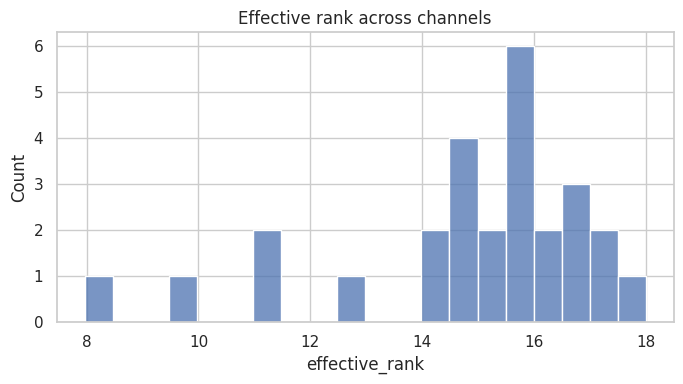

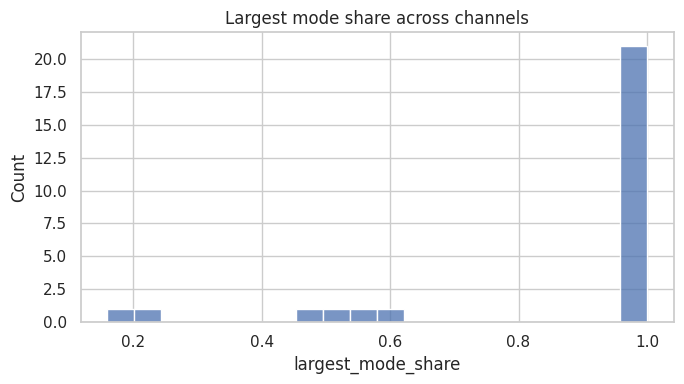

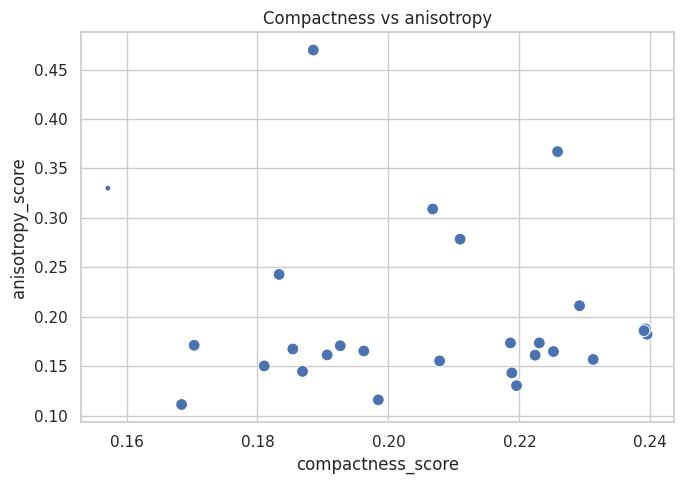

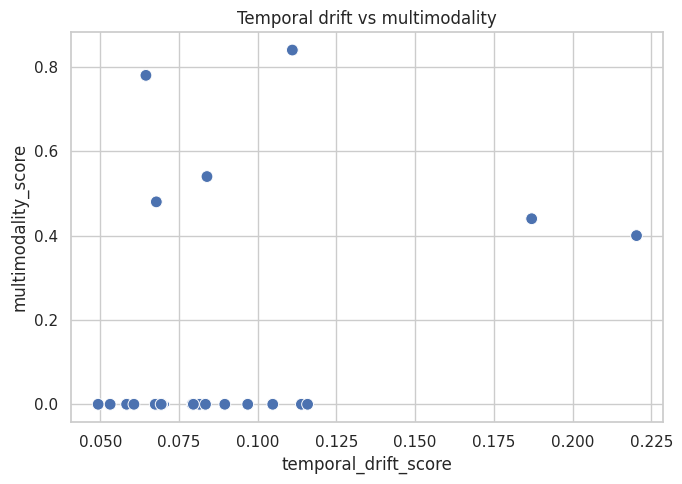

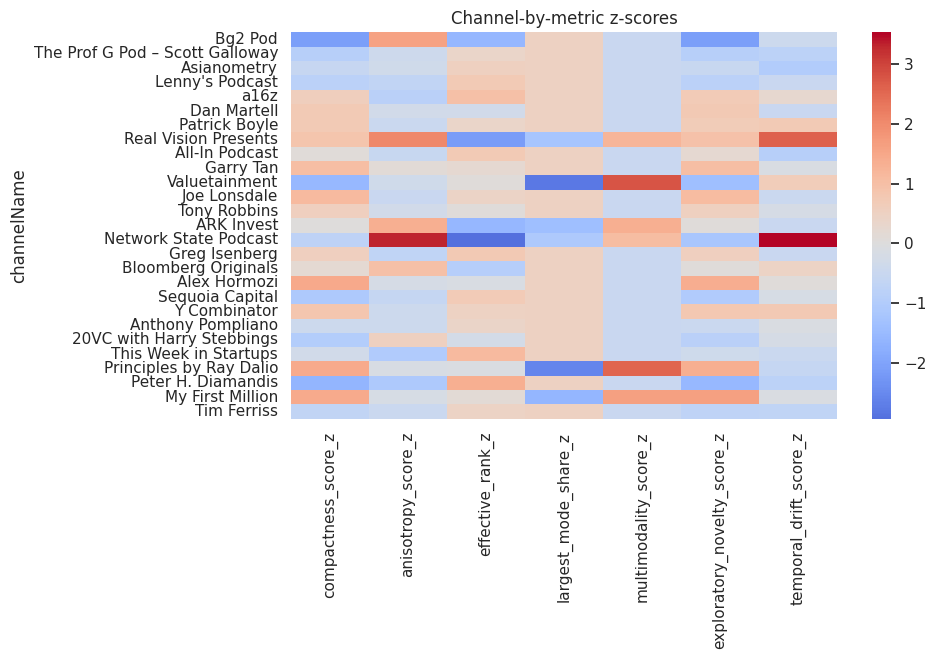

Cross-channel plots saved: artifacts/channel_video_geometry/plots/cross_channel


In [16]:

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(channel_summary["effective_rank"].dropna(), bins=20, ax=ax)
ax.set_title("Effective rank across channels")
fig.tight_layout()
fig.savefig(PLOTS_CROSS / "hist_effective_rank.png", dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(channel_summary["largest_mode_share"].dropna(), bins=20, ax=ax)
ax.set_title("Largest mode share across channels")
fig.tight_layout()
fig.savefig(PLOTS_CROSS / "hist_largest_mode_share.png", dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=channel_summary, x="compactness_score", y="anisotropy_score", size="n_videos", legend=False, ax=ax)
ax.set_title("Compactness vs anisotropy")
fig.tight_layout()
fig.savefig(PLOTS_CROSS / "scatter_compactness_vs_anisotropy.png", dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=channel_summary, x="temporal_drift_score", y="multimodality_score", size="n_videos", legend=False, ax=ax)
ax.set_title("Temporal drift vs multimodality")
fig.tight_layout()
fig.savefig(PLOTS_CROSS / "scatter_temporal_drift_vs_multimodality.png", dpi=150)
plt.show()
plt.close(fig)

metric_cols = [
    "compactness_score", "anisotropy_score", "effective_rank", "largest_mode_share",
    "multimodality_score", "exploratory_novelty_score", "temporal_drift_score"
]
heat = channel_summary[["channelName"] + metric_cols].copy()
for c in metric_cols:
    std = heat[c].std(ddof=0)
    heat[c + "_z"] = 0.0 if (pd.isna(std) or std == 0) else (heat[c] - heat[c].mean()) / std
z_cols = [c + "_z" for c in metric_cols]
heat_mat = heat.set_index("channelName")[z_cols]

fig, ax = plt.subplots(figsize=(10, max(4, 0.25 * len(heat_mat))))
sns.heatmap(heat_mat, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Channel-by-metric z-scores")
fig.tight_layout()
fig.savefig(PLOTS_CROSS / "heatmap_channel_metric_zscores.png", dpi=150)
plt.show()
plt.close(fig)

print("Cross-channel plots saved:", PLOTS_CROSS)


## 11) Advanced channel geometry overlays
Adds three interpretability visuals: (1) PCA cloud ellipses per channel, (2) two gradient-arrow performance charts (time drift and subscription asymmetry), and (3) per-channel radar polygon with external channel context clusters.


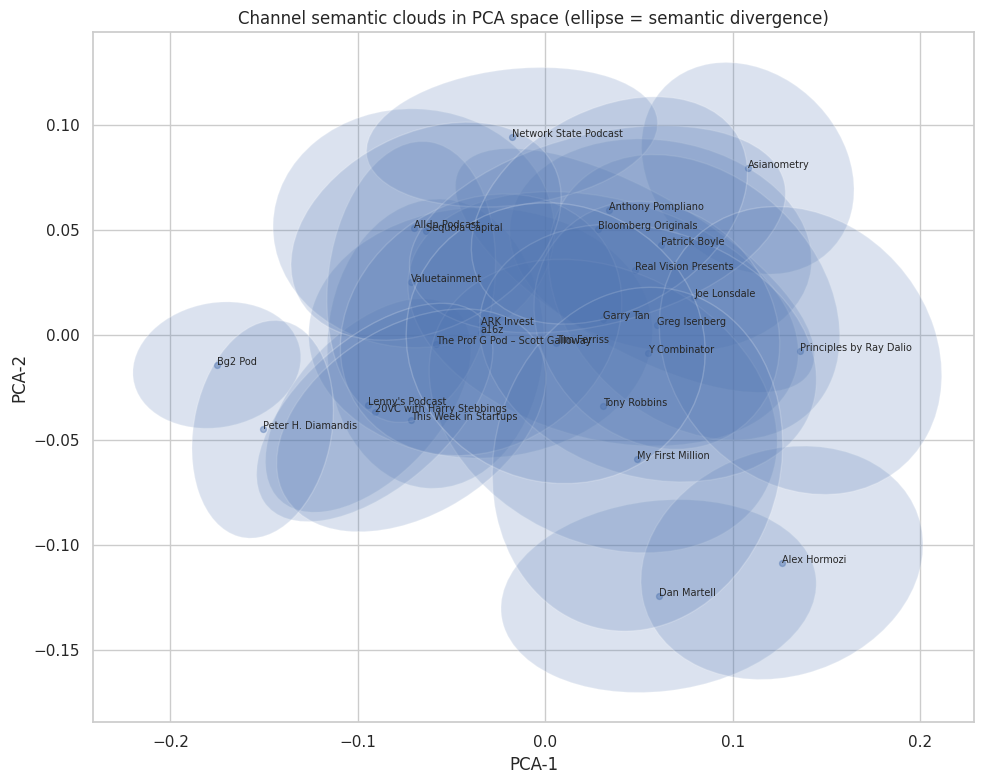

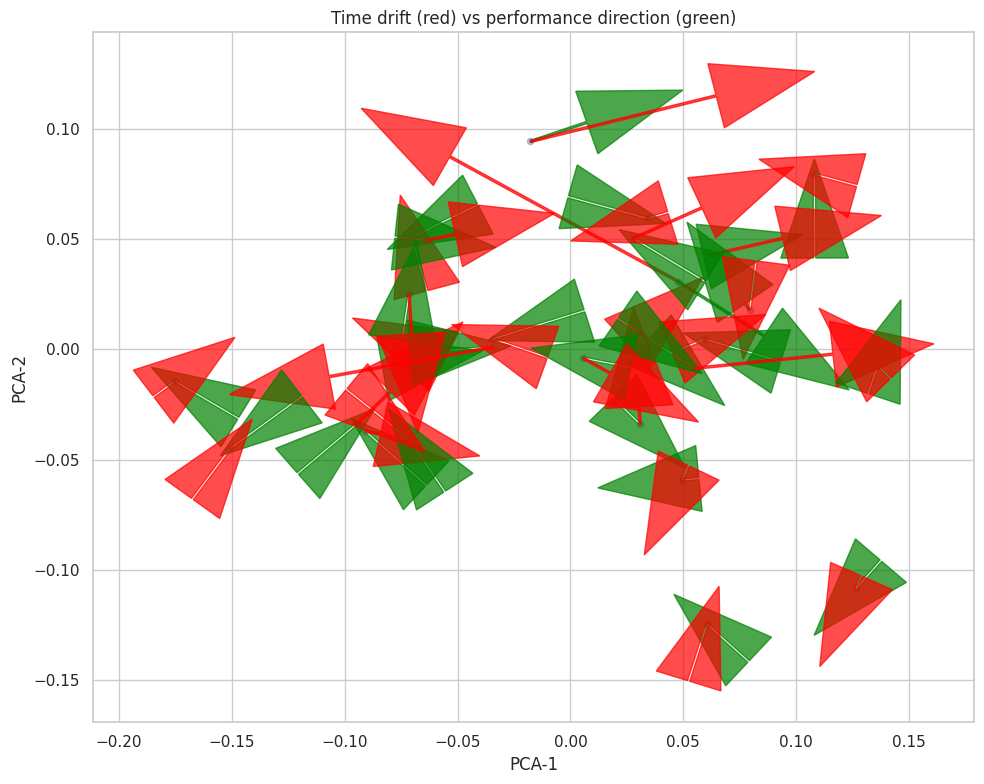

Subscription matrix not found; skipped subscription-asymmetry arrow chart.


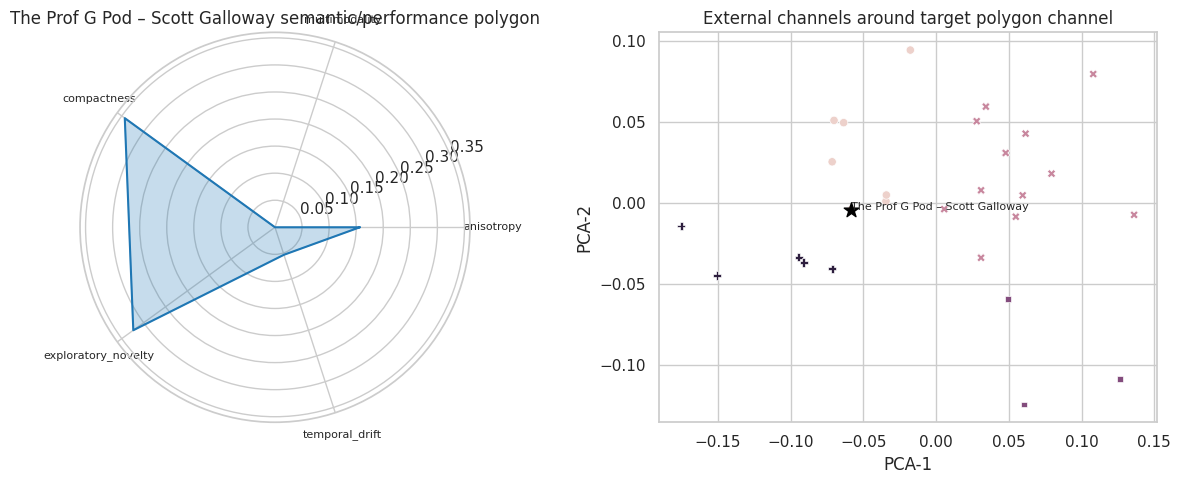

Advanced overlays saved in artifacts/channel_video_geometry/plots/cross_channel


In [18]:

from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Performance proxy: robust log blend of engagement metrics.
perf_components = []
for col in ["viewCount", "likeCount", "commentCount"]:
    if col in video_df.columns:
        perf_components.append(np.log1p(video_df[col].fillna(0.0).to_numpy()))
if perf_components:
    perf_stack = np.vstack(perf_components).T
    perf_z = StandardScaler().fit_transform(perf_stack)
    video_df["performance_score"] = perf_z.mean(axis=1)
else:
    video_df["performance_score"] = 0.0

video_scores = video_scores.merge(
    video_df[["videoId", "viewCount", "likeCount", "commentCount", "performance_score"]],
    on="videoId",
    how="left",
)

channel_pca_rows = []
for channel_id, g in video_scores.groupby("channelId", sort=False):
    X2 = g[["pca2_x", "pca2_y"]].to_numpy()
    if len(X2) < 2:
        cov = np.eye(2) * 1e-6
    else:
        cov = np.cov(X2.T)
    evals, evecs = np.linalg.eigh(cov)
    order = np.argsort(evals)[::-1]
    evals = np.clip(evals[order], 1e-9, None)
    evecs = evecs[:, order]
    angle = float(np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0])))

    # time evolution vector in reduced space
    gg = g.sort_values("publishedAt")
    split = max(1, len(gg) // 3)
    old_c = gg.head(split)[["pca2_x", "pca2_y"]].mean().to_numpy()
    new_c = gg.tail(split)[["pca2_x", "pca2_y"]].mean().to_numpy()
    drift_vec = new_c - old_c

    # performance gradient vector in reduced space
    top_perf = gg.nlargest(max(1, split), "performance_score")
    perf_c = top_perf[["pca2_x", "pca2_y"]].mean().to_numpy()
    centroid_2d = gg[["pca2_x", "pca2_y"]].mean().to_numpy()
    perf_vec = perf_c - centroid_2d

    channel_pca_rows.append({
        "channelId": channel_id,
        "channelName": gg["channelName"].iloc[0],
        "center_x": float(centroid_2d[0]),
        "center_y": float(centroid_2d[1]),
        "ellipse_width": float(2.0 * np.sqrt(evals[0])),
        "ellipse_height": float(2.0 * np.sqrt(evals[1])),
        "ellipse_angle_deg": angle,
        "perf_vec_x": float(perf_vec[0]),
        "perf_vec_y": float(perf_vec[1]),
        "drift_vec_x": float(drift_vec[0]),
        "drift_vec_y": float(drift_vec[1]),
    })

channel_pca = pd.DataFrame(channel_pca_rows)

# 1) PCA cloud ellipses per channel
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(channel_pca["center_x"], channel_pca["center_y"], s=18, alpha=0.4)
for _, r in channel_pca.iterrows():
    e = Ellipse(
        xy=(r["center_x"], r["center_y"]),
        width=r["ellipse_width"],
        height=r["ellipse_height"],
        angle=r["ellipse_angle_deg"],
        alpha=0.2,
        linewidth=1.0,
    )
    ax.add_patch(e)
    ax.text(r["center_x"], r["center_y"], r["channelName"], fontsize=7)
ax.set_title("Channel semantic clouds in PCA space (ellipse = semantic divergence)")
ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")
fig.tight_layout()
fig.savefig(PLOTS_CROSS / "pca_channel_cloud_ellipses.png", dpi=160)
plt.show()
plt.close(fig)

# 2A) Time drift vs performance arrows
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(channel_pca["center_x"], channel_pca["center_y"], s=20, alpha=0.4)
for _, r in channel_pca.iterrows():
    ax.arrow(r["center_x"], r["center_y"], r["perf_vec_x"], r["perf_vec_y"],
             color="green", alpha=0.7, head_width=0.03, length_includes_head=True)
    ax.arrow(r["center_x"], r["center_y"], r["drift_vec_x"], r["drift_vec_y"],
             color="red", alpha=0.7, head_width=0.03, length_includes_head=True)
ax.set_title("Time drift (red) vs performance direction (green)")
ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")
fig.tight_layout()
fig.savefig(PLOTS_CROSS / "pca_time_drift_vs_performance_arrows.png", dpi=160)
plt.show()
plt.close(fig)

# 2B) Subscription asymmetry vs performance arrows (if subscriptions available)
def resolve_subscriptions_counts():
    candidates = [
        Path("artifacts/graph_similarity/latest/matrix_subscriptions.csv"),
        Path("artifacts/graph_similarity/matrix_subscriptions.csv"),
        Path("artifacts/subscriptions/subscriptions_adjacency_matrix.csv"),
    ]
    for p in candidates:
        if p.exists():
            mat = pd.read_csv(p, index_col=0)
            return p, mat.sum(axis=0)
    return None, None

subs_path, subs_counts = resolve_subscriptions_counts()
if subs_counts is not None:
    name_to_subs = subs_counts.to_dict()
    channel_pca["subscription_count"] = channel_pca["channelId"].map(name_to_subs).fillna(0.0)

    # expected subscriptions from semantic position
    A = np.c_[np.ones(len(channel_pca)), channel_pca[["center_x", "center_y"]].to_numpy()]
    y = np.log1p(channel_pca["subscription_count"].to_numpy())
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    yhat = A @ coef
    channel_pca["subscription_asymmetry"] = y - yhat

    # red arrow: direction to local oversubscription maximum using nearest asymmetric peer
    red_dx, red_dy = [], []
    pts = channel_pca[["center_x", "center_y"]].to_numpy()
    asym = channel_pca["subscription_asymmetry"].to_numpy()
    for i in range(len(channel_pca)):
        better = np.where(asym > asym[i])[0]
        if len(better) == 0:
            red_dx.append(0.0); red_dy.append(0.0); continue
        j = better[np.argmin(np.linalg.norm(pts[better] - pts[i], axis=1))]
        vec = pts[j] - pts[i]
        red_dx.append(float(vec[0])); red_dy.append(float(vec[1]))

    channel_pca["subs_vec_x"] = red_dx
    channel_pca["subs_vec_y"] = red_dy

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(channel_pca["center_x"], channel_pca["center_y"], s=20, alpha=0.4)
    for _, r in channel_pca.iterrows():
        ax.arrow(r["center_x"], r["center_y"], r["perf_vec_x"], r["perf_vec_y"],
                 color="green", alpha=0.7, head_width=0.03, length_includes_head=True)
        ax.arrow(r["center_x"], r["center_y"], r["subs_vec_x"], r["subs_vec_y"],
                 color="red", alpha=0.7, head_width=0.03, length_includes_head=True)
    ax.set_title("Subscription asymmetry (red) vs performance direction (green)")
    ax.set_xlabel("PCA-1")
    ax.set_ylabel("PCA-2")
    fig.tight_layout()
    fig.savefig(PLOTS_CROSS / "pca_subscription_asymmetry_vs_performance_arrows.png", dpi=160)
    plt.show()
    plt.close(fig)
    print("Subscription matrix loaded from:", subs_path)
else:
    print("Subscription matrix not found; skipped subscription-asymmetry arrow chart.")

# 3) Target-channel radar polygon + external context clusters
TARGET_CHANNEL = channel_summary.sort_values("n_videos", ascending=False)["channelId"].iloc[0]
radar_cols = ["anisotropy_score", "multimodality_score", "compactness_score", "exploratory_novelty_score", "temporal_drift_score"]
radar = channel_summary[["channelId", "channelName", *radar_cols]].copy()
for c in radar_cols:
    lo, hi = radar[c].min(), radar[c].max()
    radar[c] = 0.5 if hi <= lo else (radar[c] - lo) / (hi - lo)

target = radar.loc[radar["channelId"] == TARGET_CHANNEL].iloc[0]
other = channel_pca.copy()
km = KMeans(n_clusters=min(4, len(other)), random_state=RANDOM_SEED, n_init=10)
other["cluster"] = km.fit_predict(other[["center_x", "center_y"]])

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="polar")
angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False)
vals = target[radar_cols].to_numpy(dtype=float)
angles_c = np.r_[angles, angles[0]]
vals_c = np.r_[vals, vals[0]]
ax1.plot(angles_c, vals_c, color="tab:blue")
ax1.fill(angles_c, vals_c, color="tab:blue", alpha=0.25)
ax1.set_xticks(angles)
ax1.set_xticklabels([c.replace("_score", "") for c in radar_cols], fontsize=8)
ax1.set_title(f"{target['channelName']} semantic/performance polygon")

ax2 = fig.add_subplot(1, 2, 2)
sns.scatterplot(data=other, x="center_x", y="center_y", hue="cluster", style="cluster", ax=ax2, legend=False)
sel = other.loc[other["channelId"] == TARGET_CHANNEL]
if not sel.empty:
    ax2.scatter(sel["center_x"], sel["center_y"], s=120, marker="*", color="black")
    ax2.text(sel["center_x"].iloc[0], sel["center_y"].iloc[0], target["channelName"], fontsize=8)
ax2.set_title("External channels around target polygon channel")
ax2.set_xlabel("PCA-1")
ax2.set_ylabel("PCA-2")
fig.tight_layout()
fig.savefig(PLOTS_CROSS / "target_channel_polygon_and_context.png", dpi=160)
plt.show()
plt.close(fig)

channel_pca.to_csv(OUTPUT / "channel_pca_semantic_overlay.csv", index=False)
print("Advanced overlays saved in", PLOTS_CROSS)


## 12) Save notebook run summary
This JSON captures run metadata, key counts, effective configuration, and canonical artifact paths for reproducible downstream consumption.


In [14]:

serializable_config = {}
for k, v in CONFIG.items():
    if isinstance(v, Path):
        serializable_config[k] = str(v)
    elif isinstance(v, list) and all(isinstance(x, Path) for x in v):
        serializable_config[k] = [str(x) for x in v]
    else:
        serializable_config[k] = v

summary = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "random_seed": RANDOM_SEED,
    "input_path": str(input_path),
    "n_videos": int(len(video_scores)),
    "n_channels": int(channel_summary["channelId"].nunique()),
    "config": serializable_config,
    "artifacts": {
        "video_geometry_scores": str(OUTPUT / "video_geometry_scores.csv"),
        "channel_geometry_summary": str(OUTPUT / "channel_geometry_summary.csv"),
        "channel_mode_summary": str(OUTPUT / "channel_mode_summary.csv"),
        "channel_covariance_eigenspectra": str(OUTPUT / "channel_covariance_eigenspectra.json"),
        "plots_per_channel": str(PLOTS_CHANNEL),
        "plots_cross_channel": str(PLOTS_CROSS),
    },
}

with open(OUTPUT / "notebook_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

summary


{'generated_at_utc': '2026-04-23T16:13:11.290014+00:00',
 'random_seed': 42,
 'input_path': '/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv',
 'n_videos': 1344,
 'n_channels': 27,
 'config': {'input_csv': '/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv',
  'fallback_inputs': ['data/business_cluster_video_embeddings_reduced_20d.csv',
   'data/video_embeddings_reduced_20d.csv'],
  'embedding_dim': 20,
  'time_decay_half_life_days': 180.0,
  'knn_k': 5,
  'min_prior_for_novelty': 5,
  'hdbscan_min_cluster_size': 6,
  'hdbscan_min_samples': 4,
  'mode_min_size_for_centroid_distance': 3,
  'output_root': 'artifacts/channel_video_geometry'},
 'artifacts': {'video_geometry_scores': 'artifacts/channel_video_geometry/video_geometry_scores.csv',
  'channel_geometry_summary': 'artifacts/channel_video_geometry/channel_geometry_summary.csv',
  'channe